In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [3]:
# Load dataset
df = pd.read_csv("../dataset/weather.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_23444\3436960449.py:2: DtypeWarning: Columns (10,11,12,13,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../dataset/weather.csv")


In [4]:
# Column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['INDEX', 'YEAR', 'MN', 'HR', 'DT', 'SLP', 'MSLP', 'DBT', 'WBT', 'DPT',
       'RH', 'VP', 'DD', 'FFF', 'AW', 'VV', 'Cl', 'A', 'Cm', 'A.1', 'Ch',
       'A.2', 'Dl', 'Dm', 'Dh', 'TC', 'h', 'c', 'a', 'Ht', 'RF', 'EVP', 'DW',
       'P', 'H', 'WAT', 'Unnamed: 36', 'Unnamed: 37'],
      dtype='object')


In [5]:
# Data information
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137285 entries, 0 to 137284
Data columns (total 38 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   INDEX        137285 non-null  int64  
 1   YEAR         137285 non-null  int64  
 2   MN           137285 non-null  int64  
 3   HR           137285 non-null  int64  
 4   DT           137285 non-null  int64  
 5   SLP          137285 non-null  float64
 6   MSLP         137285 non-null  float64
 7   DBT          137229 non-null  float64
 8   WBT          137273 non-null  float64
 9   DPT          137259 non-null  float64
 10  RH           137285 non-null  object 
 11  VP           137285 non-null  object 
 12  DD           137285 non-null  object 
 13  FFF          137285 non-null  object 
 14  AW           137285 non-null  object 
 15  VV           137285 non-null  object 
 16  Cl           137285 non-null  object 
 17  A            137285 non-null  object 
 18  Cm       

In [6]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
INDEX            0
YEAR             0
MN               0
HR               0
DT               0
SLP              0
MSLP             0
DBT             56
WBT             12
DPT             26
RH               0
VP               0
DD               0
FFF              0
AW               0
VV               0
Cl               0
A                0
Cm               0
A.1              0
Ch               0
A.2              0
Dl               0
Dm               0
Dh               0
TC               0
h                0
c                0
a                0
Ht               0
RF               0
EVP              0
DW             316
P                0
H                0
WAT              0
Unnamed: 36      0
Unnamed: 37      0
dtype: int64


In [7]:
# Drop useless columns
df.drop(['Unnamed: 36', 'Unnamed: 37'], axis=1, inplace=True)

# Check shape again
df.shape

(137285, 36)

In [8]:
df['RF'].unique()[:20]

array(['4', ' ', '0', '3', '1', '2', '5', '7', '6', '8', '9'],
      dtype=object)

In [9]:
# Replace blank spaces with NaN
df['RF'] = df['RF'].replace(' ', pd.NA)

In [10]:
# Convert RF column to numeric
df['RF'] = pd.to_numeric(df['RF'])

In [11]:
df['RF'].dtype

dtype('float64')

In [12]:
df['RF'].isnull().sum()

np.int64(4871)

In [13]:
# Remove rows where RF is missing
df = df.dropna(subset=['RF'])

# Check remaining missing values
df['RF'].isnull().sum()

np.int64(0)

In [14]:
# Create Rain column
df['Rain'] = df['RF'].apply(lambda x: 1 if x > 0 else 0)

# Check first rows
df[['RF', 'Rain']].head()

,RF,Rain
0,4.0,1
2,0.0,0
3,0.0,0
4,3.0,1
5,1.0,1


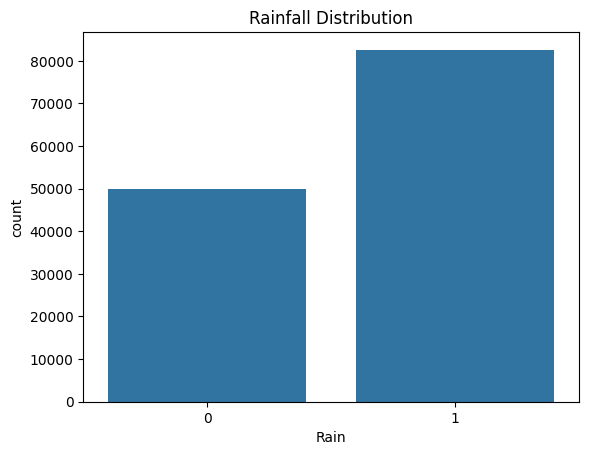

In [15]:
# Count plot
sns.countplot(x='Rain', data=df)
plt.title("Rainfall Distribution")
plt.show()

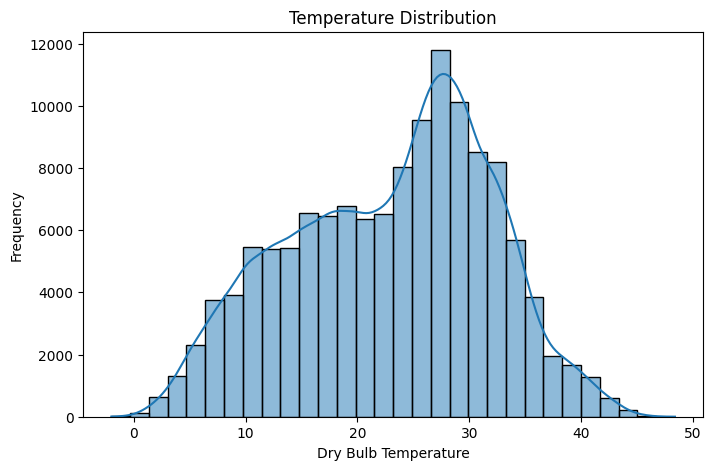

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['DBT'], bins=30, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Dry Bulb Temperature")
plt.ylabel("Frequency")

plt.show()

In [17]:
important_cols = ['RH', 'VP', 'FFF', 'VV', 'TC']

for col in important_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique()[:10])


Column: RH
['89' '96' '90' '84' '86' '94' '100' '97' '93' '83']

Column: VP
['9.4' '6.9' '6.1' '7.6' '7.7' '7.2' '9.2' '9.7' '10' '9.5']

Column: FFF
['12' '10' '8' '16' '6' '14' '4' '0' '22' '18']

Column: VV
[96 95 94 97 93 92 91 90 99 '94']

Column: TC
['5' '0' '3' '1' '8' '2' '7' '4' '6' '}']


In [18]:
# Replace invalid symbols with NaN
df['TC'] = df['TC'].replace('}', pd.NA)

In [19]:
# convert imp. columns into numeric
numeric_cols = ['RH', 'VP', 'FFF', 'VV', 'TC']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [20]:
df[numeric_cols].dtypes

RH     float64
VP     float64
FFF    float64
VV     float64
TC     float64
dtype: object

In [21]:
df[numeric_cols].isnull().sum()

RH      25
VP      43
FFF    153
VV       1
TC      24
dtype: int64

In [22]:
# fill missing values
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
df[numeric_cols].isnull().sum()

RH     0
VP     0
FFF    0
VV     0
TC     0
dtype: int64

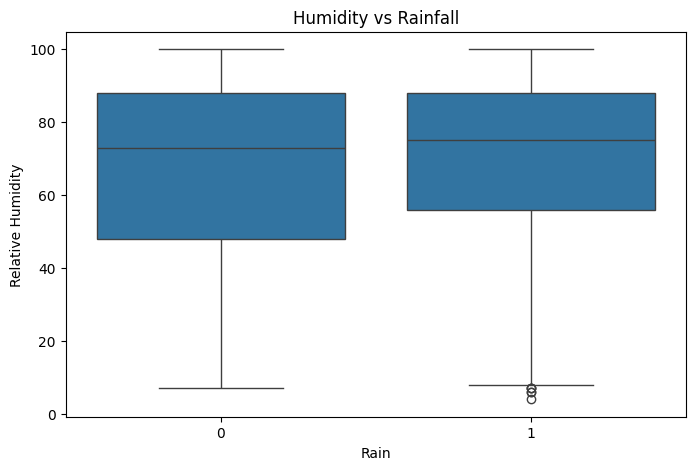

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Rain', y='RH', data=df)

plt.title("Humidity vs Rainfall")

plt.xlabel("Rain")
plt.ylabel("Relative Humidity")

plt.show()

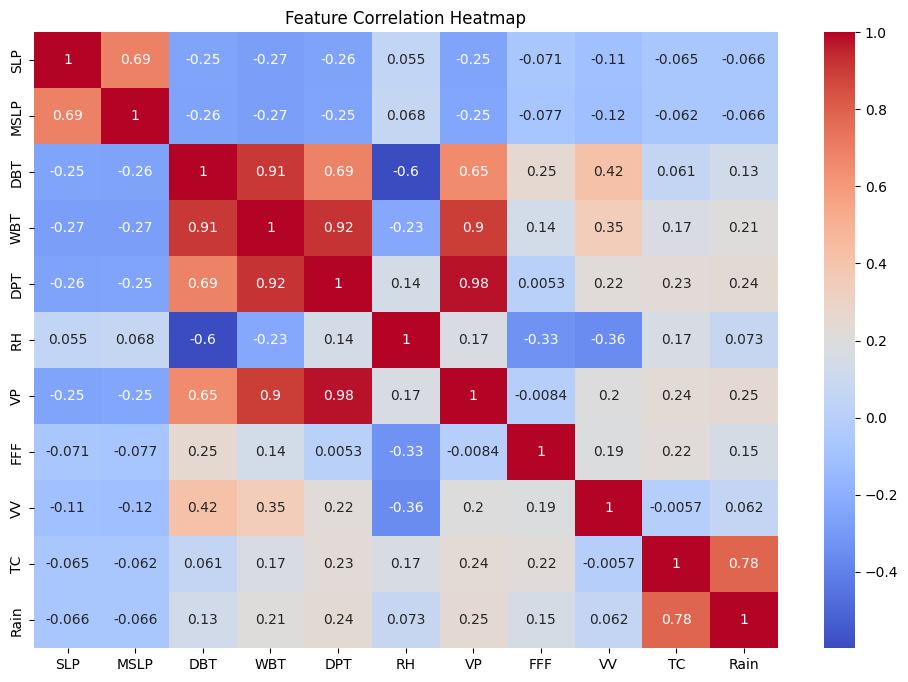

In [25]:
plt.figure(figsize=(12,8))

correlation = df[['SLP', 'MSLP', 'DBT', 'WBT', 'DPT',
                  'RH', 'VP', 'FFF', 'VV', 'TC', 'Rain']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [26]:
features = ['SLP', 'MSLP', 'DBT', 'WBT','DPT', 'RH', 'VP', 'FFF','VV', 'TC']
# Fill missing values in selected features
for col in features:
    df[col] = df[col].fillna(df[col].median())

In [27]:
df[features].isnull().sum()

SLP     0
MSLP    0
DBT     0
WBT     0
DPT     0
RH      0
VP      0
FFF     0
VV      0
TC      0
dtype: int64

In [28]:
X = df[features]
y = df['Rain']

In [29]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [30]:
# Create model
lr = LogisticRegression(max_iter=1000)

# Train model
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9988294377525205


In [31]:
features2 = ['SLP', 'MSLP', 'DBT','WBT', 'RH', 'FFF', 'VV']

X = df[features2]

y = df['Rain']


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("New Logistic Regression Accuracy:", accuracy)

New Logistic Regression Accuracy: 0.6383340256013291


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6637465543933845


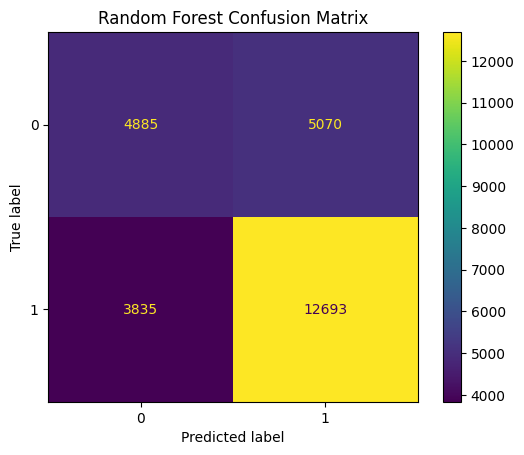

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Display matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.56      0.49      0.52      9955
           1       0.71      0.77      0.74     16528

    accuracy                           0.66     26483
   macro avg       0.64      0.63      0.63     26483
weighted avg       0.66      0.66      0.66     26483



In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Create model
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.6853830759355058


In [38]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.60      0.48      0.53      9955
           1       0.72      0.81      0.76     16528

    accuracy                           0.69     26483
   macro avg       0.66      0.64      0.65     26483
weighted avg       0.68      0.69      0.68     26483



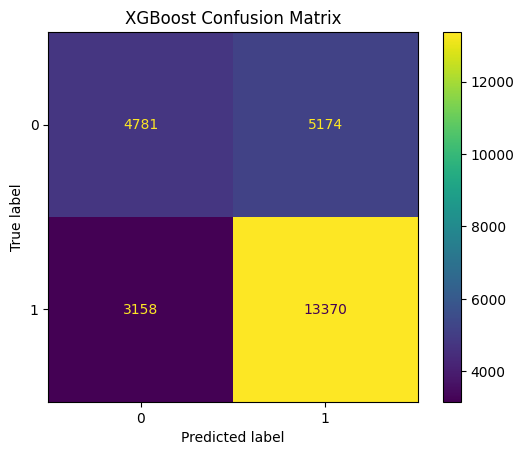

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)

disp.plot()

plt.title("XGBoost Confusion Matrix")

plt.show()

In [40]:
# Base models
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
]

# Stacking model
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)

# Accuracy
stack_accuracy = accuracy_score(y_test, y_pred_stack)


print("Stacking Classifier Accuracy:", stack_accuracy)

Stacking Classifier Accuracy: 0.6863648378204886


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_stack))

              precision    recall  f1-score   support

           0       0.60      0.48      0.54      9955
           1       0.72      0.81      0.76     16528

    accuracy                           0.69     26483
   macro avg       0.66      0.65      0.65     26483
weighted avg       0.68      0.69      0.68     26483



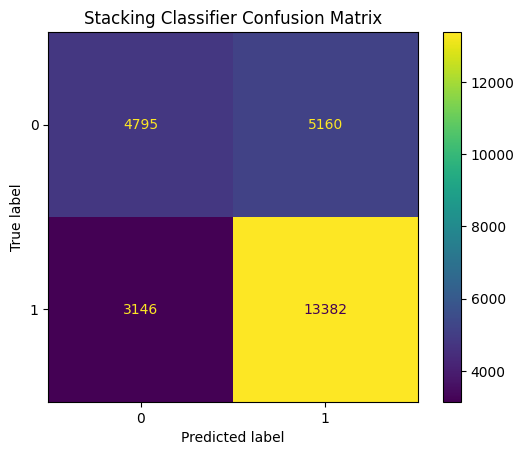

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm_stack = confusion_matrix(y_test, y_pred_stack)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stack)

disp.plot()

# Title
plt.title("Stacking Classifier Confusion Matrix")

# Show plot
plt.show()

In [43]:
def get_season(month):
    if month in [12, 1, 2]:
        return 0   # Winter
    elif month in [3, 4, 5]:
        return 1   # Summer
    elif month in [6, 7, 8, 9]:
        return 2   # Monsoon
    else:
        return 3   # Post-Monsoon

df['Season'] = df['MN'].apply(get_season)

In [44]:
features4 = ['SLP', 'MSLP', 'DBT',
             'WBT', 'DPT', 'RH',
             'VP', 'FFF', 'VV',
             'Season']

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.6873088396329721


In [46]:
df['Temp_Humidity'] = df['DBT'] * df['RH']

df['Pressure_Diff'] = df['MSLP'] - df['SLP']

In [47]:
features_final = ['SLP', 'MSLP', 'DBT',
                  'WBT', 'RH',
                  'FFF', 'VV',
                  'Season', 'MN',
                  'Temp_Humidity',
                  'Pressure_Diff']

In [48]:
X = df[features_final]
y = df['Rain']

In [49]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [50]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.7293358003247367


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.67      0.55      0.61      9955
           1       0.76      0.84      0.79     16528

    accuracy                           0.73     26483
   macro avg       0.71      0.69      0.70     26483
weighted avg       0.72      0.73      0.72     26483



In [52]:
import pandas as pd

# Example user input
input_data = pd.DataFrame([{
    'SLP': 990,
    'MSLP': 1015,
    'DBT': 28,
    'WBT': 24,
    'RH': 85,
    'FFF': 12,
    'VV': 90,
    'Season': 2,
    'MN': 7,
    'Temp_Humidity': 28 * 85,
    'Pressure_Diff': 1015 - 990
}])

In [53]:
probability = xgb.predict_proba(input_data)[0][1]

print(probability)

0.92894065


In [54]:
print(f"Rain Probability: {probability*100:.2f}%")

Rain Probability: 92.89%


In [55]:
prediction = xgb.predict(input_data)

if prediction[0] == 1:
    print("Rain Expected")
else:
    print("No Rain Expected")

Rain Expected


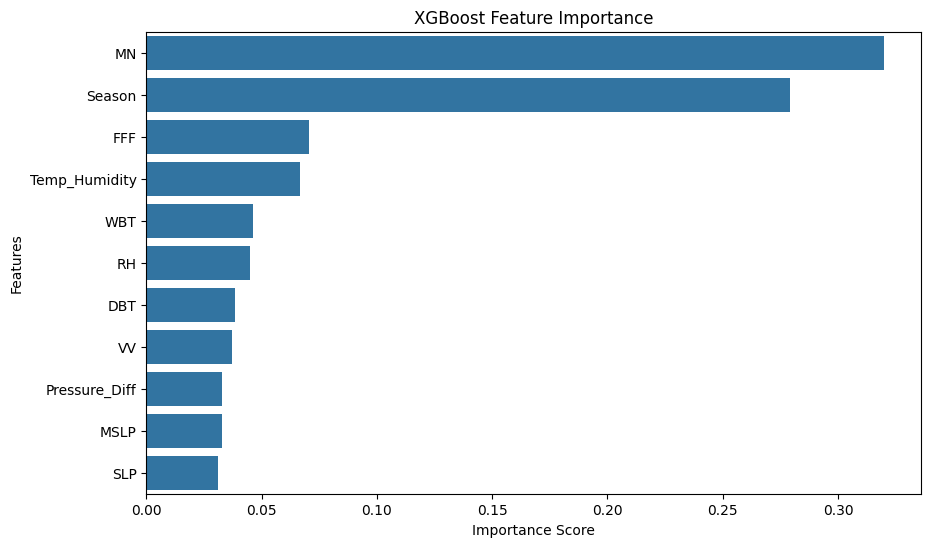

In [56]:

# Feature importance values
importance = xgb.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': features_final,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot graph
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [57]:
import joblib

# File path
fileName_weather = "../models/weather_xgboost_model.joblib"

# Save model
joblib.dump(xgb, fileName_weather)

['../models/weather_xgboost_model.joblib']

In [58]:

model = joblib.load("../models/weather_xgboost_model.joblib")

In [59]:
features_final = [
    'SLP',
    'MSLP',
    'DBT',
    'WBT',
    'RH',
    'FFF',
    'VV',
    'Season',
    'MN',
    'Temp_Humidity',
    'Pressure_Diff'
]

In [60]:

fileName_feature = "../models/feature.joblib"

# Save model
joblib.dump(features_final, fileName_feature)



['../models/feature.joblib']

In [61]:
name= joblib.load("../models/feature.joblib")

In [62]:
sample_df = df.sample(3000, random_state=42)

sample_df.to_csv(
    r"C:\Users\hp\Desktop\Weather-Intelligence-System\dataset\weather_sample.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!
